# 画迭代迁移学习图

In [1]:
import sys
sys.path.append("../")
from tools import getPairInfo, metric
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np
import torch
import os
import re
from matplotlib import rc
import matplotlib.patches as patches
from scipy.stats import wilcoxon

def getPath(path):
    def keys(x):
        dev = float(re.findall('devR2=(-?\d+.\d+)', x)[0])
        train = float(re.findall('trainR2:(-?\d+.\d+)', x)[0])
        return 0.6*dev + 0.4*train
    fileList = os.listdir(path)
    fileList.sort(key=keys, reverse=True)
    return os.path.join(path, fileList[0])
def err(x, y):
    x = np.array(x)
    y = np.array(y)
    return x-y

In [9]:
results = []
from predictor_iter import predict
kineticsType = 'km'
AbsoluteError = []
for i in range(1, 9):
    real, pre = predict(
            kineticsType.upper(),
            getPath(f"../../IterTransferLearning/{kineticsType.upper()}Model/confirm-MACCS#openKKmInfer#openLog10-{kineticsType.upper()}-train-{i}/model/"),
            torch.load(f"../Data/{kineticsType.upper()}TestPairInfo"),
            f"../../{kineticsType.upper()}/Data/NewestFeature/esm1v_t33_650M_UR90S_1_embeding_1280/",
            f"../../{kineticsType.upper()}/Data/NewestFeature/index_smiles",
            True,
            torch.device("cuda:0"),
            "MACCSKeys"
    )
    res = metric(pre, real, True)
    results.append(res)
    AbsoluteError.append(err(pre, real))

log10:True molType:MACCSKeys
F


100%|█████████████████████████████████████████████████████████████| 29/29 [00:11<00:00,  2.44it/s]


log10:True molType:MACCSKeys
F


100%|█████████████████████████████████████████████████████████████| 29/29 [00:08<00:00,  3.53it/s]


log10:True molType:MACCSKeys
F


...

100%|█████████████████████████████████████████████████████████████| 29/29 [00:08<00:00,  3.56it/s]


log10:True molType:MACCSKeys
F


100%|█████████████████████████████████████████████████████████████| 29/29 [00:07<00:00,  3.63it/s]


log10:True molType:MACCSKeys
F


100%|█████████████████████████████████████████████████████████████| 29/29 [00:07<00:00,  3.87it/s]


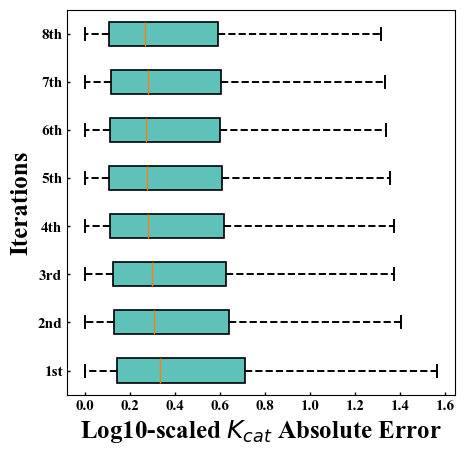

In [7]:
import matplotlib.pyplot as plt
from matplotlib import rc
plt.figure(figsize=(5,5))
rc('font',**{'family':'Times New Roman',})

plt.tick_params(direction='in')
plt.tick_params(which='major',length=2)
plt.tick_params(which='major',width=1)

artist = plt.boxplot([np.abs(item) for item in AbsoluteError], 
            patch_artist=True, 
            labels=['1st', '2nd', '3rd', '4th', '5th', '6th', '7th', '8th'],
            showfliers=False,
            vert=False,
            boxprops={'facecolor':'#5EC2BB', 'color':'black', 'linewidth':1.2},
            whiskerprops={'linestyle':'--', 'lw':1.4},
            capprops={'lw':1.4},
           )
# plt.xticks(np.arange(0, 2.4, 0.2),fontsize=12, weight='normal')
plt.yticks(fontsize=11, weight='bold')
plt.xticks(fontsize=11, weight='bold')
plt.ylabel("Iterations", fontsize=18, weight='bold')
plt.xlabel("Log10-scaled $K_{cat}$ Absolute Error", fontsize=18, weight='bold')
plt.savefig(f"../Fig/Fig8-MACCSKeys-boxplot-{kineticsType}.png", dpi=600, bbox_inches='tight')

In [10]:
import scipy.stats as stats
hd = np.zeros((8, 8))
for i in range(8):
    for j in range(i+1, 8):
        _, p = stats.wilcoxon(AbsoluteError[i], AbsoluteError[j], alternative='two-sided')
        hd[i][j] = p

In [13]:
hd[hd==0] = 1
mask = (hd<0.05)
hd[mask] = 1
hd[~mask] = 0

In [11]:
import pandas as pd
pd.DataFrame(hd + hd.T)

,0,1,2,3,4,5,6,7
0,0.000000e+00,1.569680e-04,8.316650e-01,1.497781e-09,7.721600e-11,4.426311e-01,2.870902e-01,4.238507e-01
1,1.569680e-04,0.000000e+00,1.851608e-10,4.250642e-10,1.337124e-84,1.385014e-07,9.105762e-18,1.896132e-05
2,8.316650e-01,1.851608e-10,0.000000e+00,4.412994e-36,4.389796e-49,5.234045e-01,3.048994e-03,5.434854e-01
3,1.497781e-09,4.250642e-10,4.412994e-36,0.000000e+00,5.502002e-151,9.003038e-33,3.995142e-46,1.300947e-27
4,7.721600e-11,1.337124e-84,4.389796e-49,5.502002e-151,0.000000e+00,1.722041e-66,1.649303e-41,7.055703e-51
5,4.426311e-01,1.385014e-07,5.234045e-01,9.003038e-33,1.722041e-66,0.000000e+00,2.779124e-06,5.114586e-01
6,2.870902e-01,9.105762e-18,3.048994e-03,3.995142e-46,1.649303e-41,2.779124e-06,0.000000e+00,2.439253e-04
7,4.238507e-01,1.896132e-05,5.434854e-01,1.300947e-27,7.055703e-51,5.114586e-01,2.439253e-04,0.000000e+00
